In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification ,load_iris
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.pipeline import Pipeline
from sklearn.metrics import recall_score , precision_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV,StratifiedKFold, learning_curve
from sklearn.metrics import recall_score, confusion_matrix, classification_report

import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd

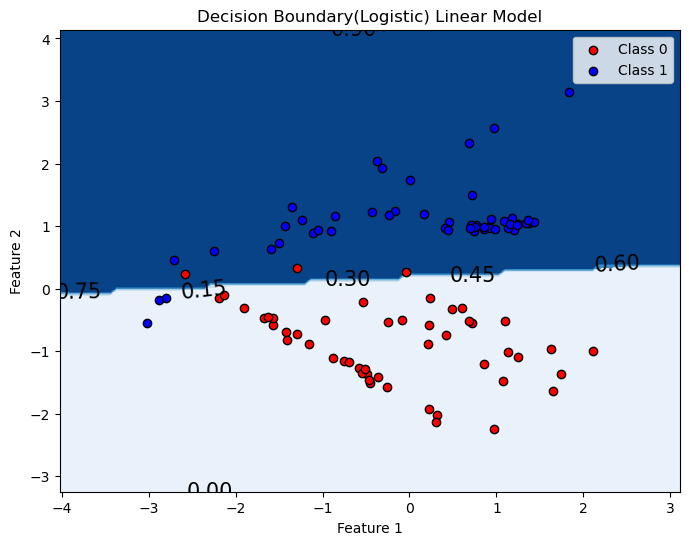

In [19]:
model = LogisticRegression()

X, y = make_classification(n_samples=100,
                           n_features=2,
                           n_redundant=0,
                           n_informative=2,
                           random_state=26 )
model.fit(X,y)

plt.figure(figsize=(8, 6))
disp= DecisionBoundaryDisplay.from_estimator(model,
                                      X,
                                      response_method='predict',
                                      plot_method='contourf' ,
                                      ax=plt.gca(),
                                      cmap='Blues',
                                       )
plt.clabel(disp.surface_, inline=True, fontsize=15, fmt='%.2f', colors='black')
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red', label='Class 0', edgecolor='k')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', label='Class 1', edgecolor='k')
plt.xlabel('Feature 1')
plt.title('Decision Boundary(Logistic) Linear Model')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


The mix region is the decision boundary where the model is uncertain to make prediction and the numbers are the probability

In [20]:
model.decision_function( [[0,1]]) ,model.predict_proba( [[0,1]]) 

(array([2.59318613]), array([[0.06957824, 0.93042176]]))

Log odds and the probability

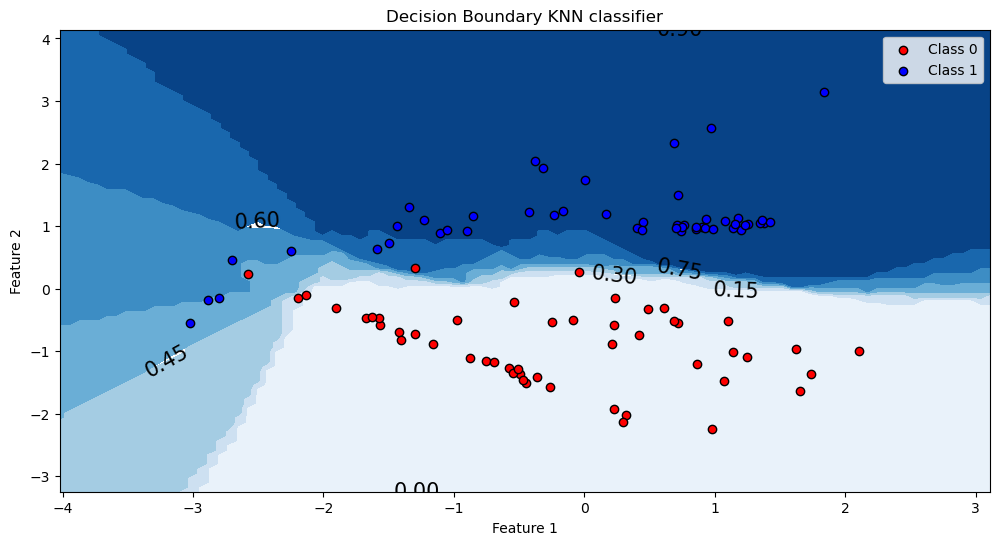

In [21]:
model_2 = KNeighborsClassifier(n_neighbors=8,
                              p=2, 
                              weights='uniform')
model_2.fit(X,y)

plt.figure(figsize=(12, 6))
disp= DecisionBoundaryDisplay.from_estimator(model_2,
                                      X,
                                      response_method='predict_proba',
                                      plot_method='contourf' ,
                                      ax=plt.gca(),
                                      cmap='Blues')
plt.clabel(disp.surface_, inline=True, fontsize=15, fmt='%.2f', colors='black')
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red', label='Class 0', edgecolor='k')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', label='Class 1', edgecolor='k')
plt.xlabel('Feature 1')
plt.title('Decision Boundary KNN classifier')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


here the knn probability is number of class 1 neighobrs / K neighbors

When weight ='distance' "Closer neighbors get a heavier vote (more influence) than farther neighbors."

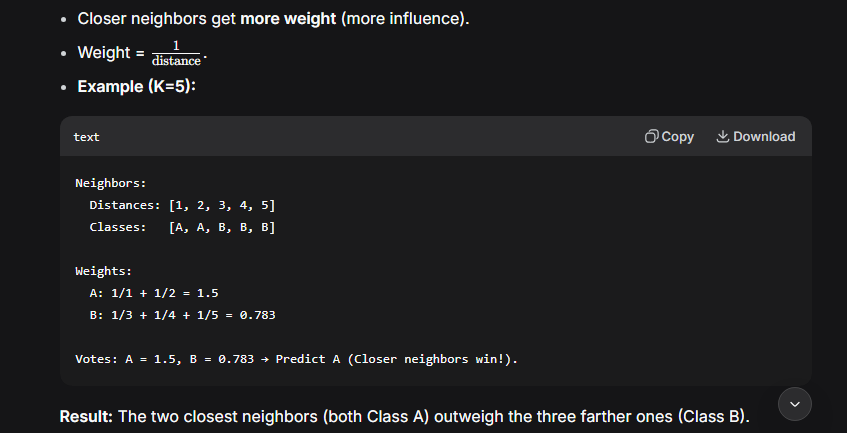

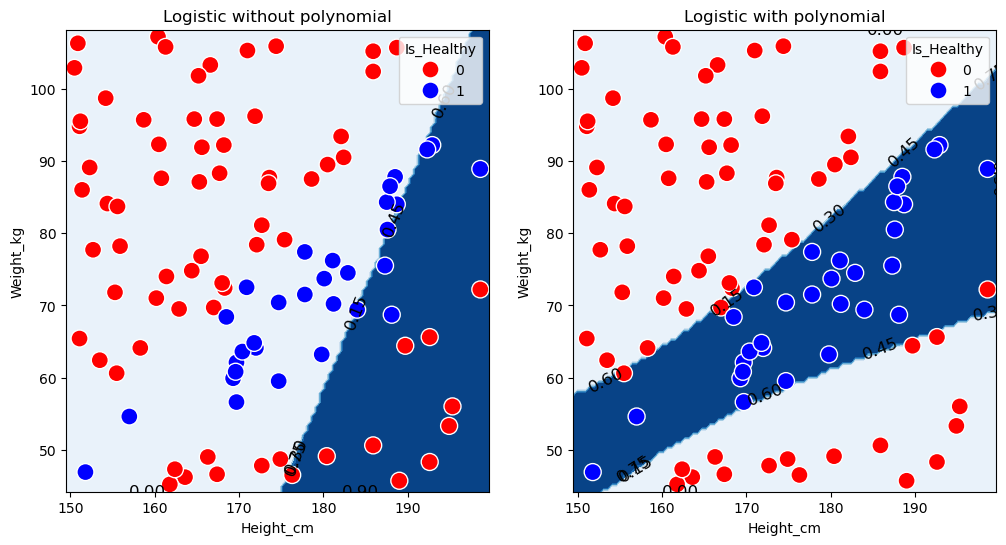

In [22]:
heights = np.random.uniform(150, 200, 100)
weights = np.random.uniform(45, 110, 100)

df = pd.DataFrame({
    'Height_cm': np.round(heights, 1),
    'Weight_kg': np.round(weights, 1)
})
bmi = df['Weight_kg'] / ((df['Height_cm'] / 100) ** 2)

df['Is_Healthy'] = np.where((bmi >= 18.5) & (bmi <= 24.9), 1, 0)
model = LogisticRegression()
X = df.drop( columns ='Is_Healthy') 
y = df['Is_Healthy']
model.fit(X, y)
model_2.fit(X,y)
fig, ax = plt.subplots( 1,2, figsize= (12,6))
disp= DecisionBoundaryDisplay.from_estimator(model,
                                      X,
                                      response_method='predict',
                                      plot_method='contourf' ,
                                      ax=ax[0],
                                      cmap='Blues')
ax[0].clabel(disp.surface_, inline=True, fontsize=12, fmt='%.2f', colors='black')
sns.scatterplot(data = df , 
                x='Height_cm' ,
                y='Weight_kg', 
                hue= 'Is_Healthy',
                s = 150, 
                palette=['Red' ,'Blue'] ,
                ax=ax[0]
               )
model_3 = Pipeline([( 'pol' , PolynomialFeatures(degree=2,
                                                 include_bias=False) ),
                    ('log_pol' , LogisticRegression(max_iter=250)) ])
model_3.fit(X,y)
disp= DecisionBoundaryDisplay.from_estimator(model_3,
                                      X,
                                      response_method='predict',
                                      plot_method='contourf' ,
                                      ax=ax[1],
                                      cmap='Blues')
ax[1].clabel(disp.surface_, inline=True, fontsize=12, fmt='%.2f', colors='black')
ax[1].set_title('Logistic with polynomial')
ax[0].set_title('Logistic without polynomial')
sns.scatterplot(data = df , 
                x='Height_cm' ,
                y='Weight_kg', 
                hue= 'Is_Healthy',
                s = 150, 
                palette=['Red' ,'Blue'] ,
                ax=ax[1]
               )
plt.show()

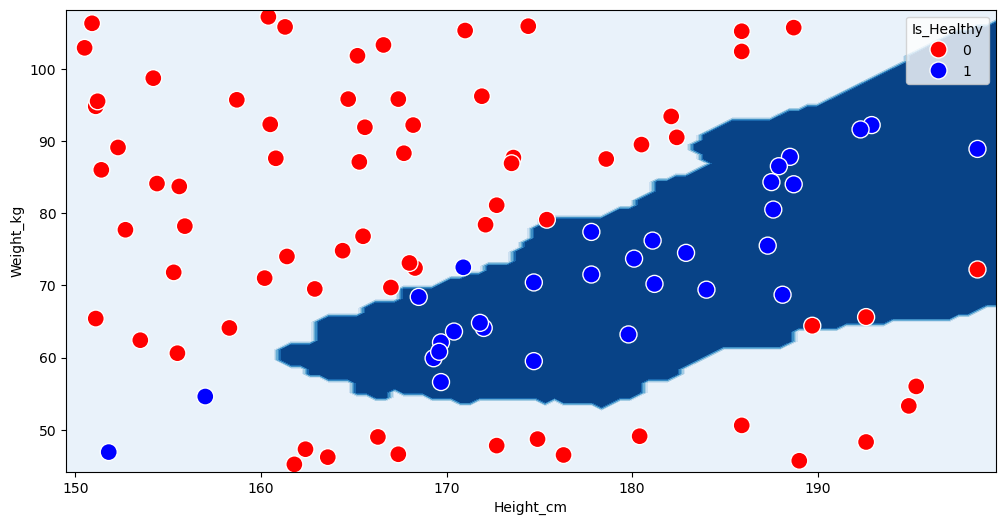

In [23]:
#with knn 
model = KNeighborsClassifier( n_neighbors=12) 
model.fit(X,y)
plt.figure( figsize =(12,6) ) 

disp = DecisionBoundaryDisplay.from_estimator( model, 
                                               X,
                                               response_method='predict' , 
                                               plot_method='contourf' , 
                                               cmap ='Blues', 
                                               ax = plt.gca() )
sns.scatterplot( data = df , 
                 x='Height_cm' ,
                 y='Weight_kg', 
                 hue= 'Is_Healthy',
                 s = 150, 
                 palette=['Red' ,'Blue'] )
plt.show()

Because the relationship between the classes is not linear the logistic regression is failing 
"The relationship between Height, Weight, and the log-odds of being Healthy is linear, but the relationship between Height, Weight, and the probability of being Healthy is non-linear."

In [24]:
recall_score( y, model.predict(X)), recall_score( y, model_3.predict(X))

(0.9032258064516129, 1.0)

In [25]:
df = load_iris(as_frame=True).frame
df.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


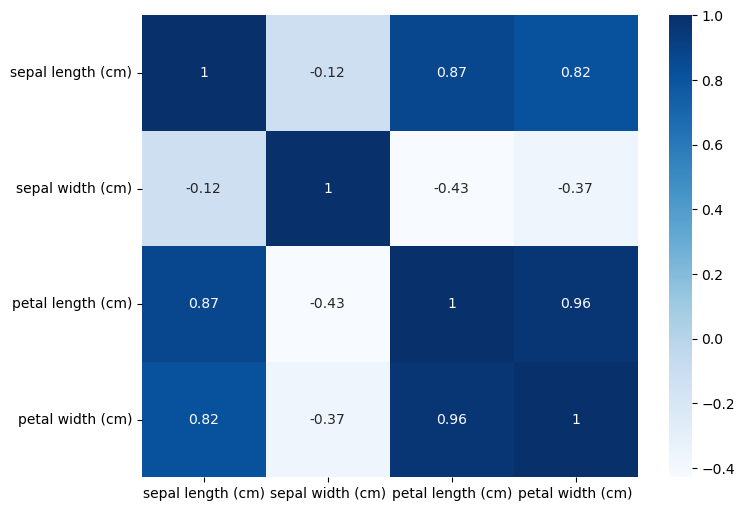

In [26]:
corr= df.drop( columns='target').corr() 
plt.figure( figsize = (8,6)) 
sns.heatmap( corr, cmap='Blues' , annot=True)
plt.show()

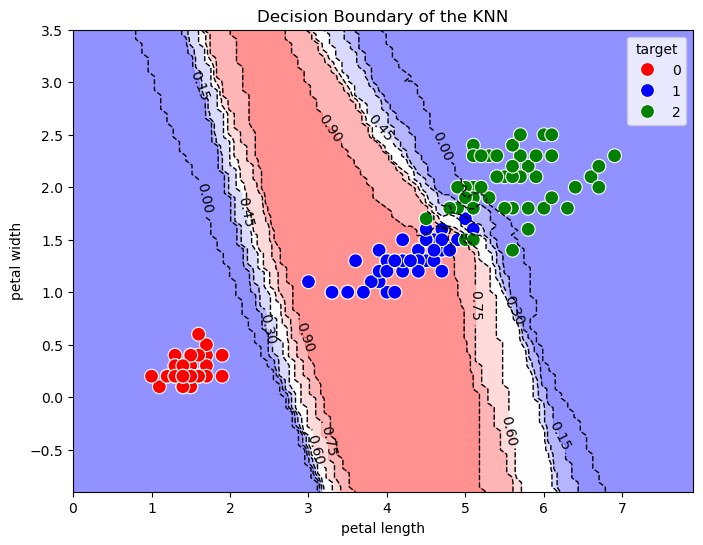

In [27]:
model = KNeighborsClassifier(
    n_neighbors=9,
    p=2,
    weights='uniform' 
)
labels = df[['petal length (cm)', 'petal width (cm)' ,'target']]

model.fit( 
    labels.drop(columns = 'target'),
    labels['target']
)

plt.figure(figsize = (8,6)) 
display = DecisionBoundaryDisplay.from_estimator(
    model,
    labels.drop(columns = 'target'),
    response_method='predict_proba',
    plot_method= 'contourf',
    ax = plt.gca(),
    class_of_interest=1, 
    cmap = 'bwr', 
    alpha = 0.5
)
display_lines = DecisionBoundaryDisplay.from_estimator(
    model, labels.drop(columns = 'target'),
    plot_method= 'contour' , response_method='predict_proba',
    colors='black', linewidths=1, linestyles='dashed',
    ax =plt.gca() ,
    class_of_interest=1, 
)
plt.clabel(
    display_lines.surface_, 
    inline=True,            
    fontsize=10,
    fmt='%.2f'             
)
sns.scatterplot( 
    data = labels ,
    x = 'petal length (cm)',
    y= 'petal width (cm)',
    hue = 'target',
    s= 100,
    palette=[ 'red','blue' , 'green']
)
plt.xlabel('petal length')
plt.ylabel('petal width')
plt.title('Decision Boundary of the KNN')
plt.show()




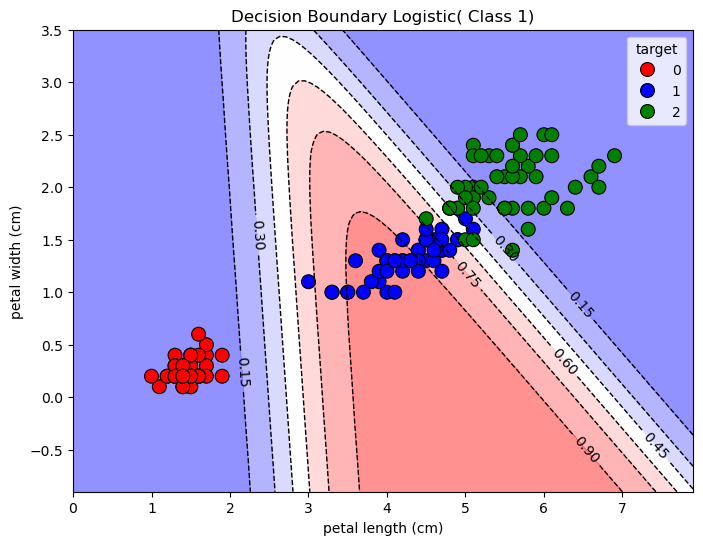

In [28]:
model = LogisticRegression()
model.fit(labels.drop(columns='target'), labels['target'])

plt.figure(figsize=(8, 6)) 
display = DecisionBoundaryDisplay.from_estimator(
    model,
    labels.drop(columns='target'),
    response_method='predict_proba',
    plot_method='contourf',
    cmap='bwr',
    alpha=0.5,
    ax=plt.gca(),
    class_of_interest=1,
)
display_lines = DecisionBoundaryDisplay.from_estimator(
    model,
    labels.drop(columns='target'),
    response_method='predict_proba',
    plot_method='contour',  
    colors='black',        
    linewidths=1,
    linestyles='dashed',   
    ax=plt.gca(),
    class_of_interest =1 , 
)
plt.clabel(
    display_lines.surface_, 
    inline=True,            
    fontsize=10,
    fmt='%.2f'             
)
sns.scatterplot(
    data=labels,
    x='petal length (cm)',
    y='petal width (cm)',
    hue='target',
    s=100,
    palette=['red', 'blue', 'green'],
    edgecolor='k'
)
plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.title('Decision Boundary Logistic( Class 1)')
plt.show()

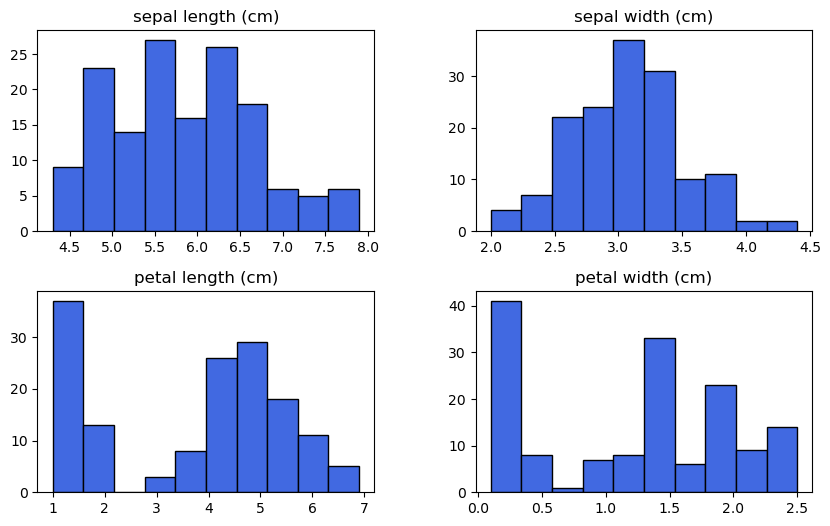

In [29]:
df.drop('target' , axis =1 ).hist(
    grid = False , 
    figsize = (10,6),
    bins = 10, color = 'royalblue', edgecolor ='black'
)
plt.show()

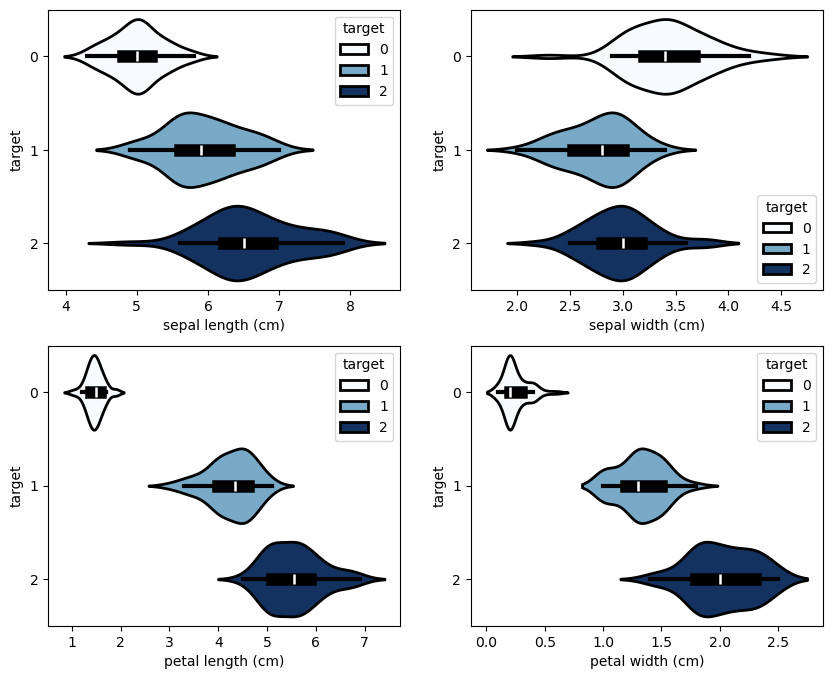

In [30]:
fig, ax = plt.subplots(2, 2, figsize=(10,8))
columns = df.drop('target', axis=1).columns
ax = ax.flatten()
for idx, val in enumerate(columns):
    sns.violinplot(
        data=df, y='target', x=val, hue='target',
        palette='Blues',
        linecolor='black', linewidth=2,
        ax=ax[idx],
        orient='h',
    )
plt.show()

In [46]:
pipeline = Pipeline([
    ('scaling', StandardScaler()),
    ('model', KNeighborsClassifier(p=2)),
])
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size = 0.2, stratify=y, shuffle=True, 
    random_state=26
)

param_grid = {
    'model__n_neighbors': [5, 10, 15, 20],
    'model__weights': ['uniform', 'distance']
}

skfolds = StratifiedKFold(n_splits=5, shuffle=True, random_state=26)
grid_search = GridSearchCV(
    pipeline, 
    param_grid=param_grid,
    cv=skfolds,
    scoring='recall_macro',
)

grid_search.fit(X,y)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'model__n_neighbors': [5, 10, ...], 'model__weights': ['uniform', 'distance']}"
,scoring,'recall_macro'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [32]:
grid_search.best_score_, grid_search.best_params_

(np.float64(0.96), {'model__n_neighbors': 10, 'model__weights': 'uniform'})

In [33]:
my_model = grid_search.best_estimator_

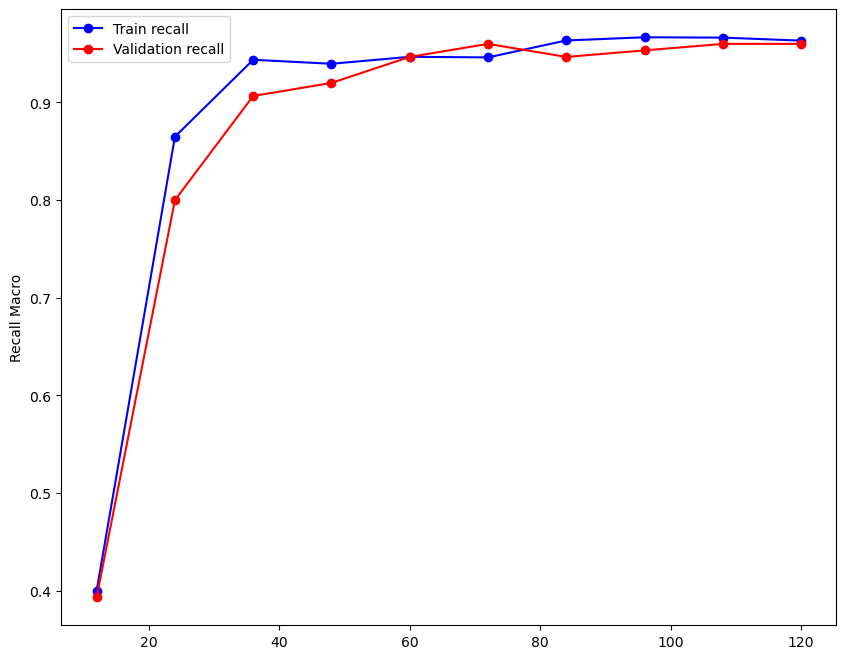

In [40]:
train_size, train_scores, test_scores = learning_curve(
    my_model,
    X,
    y,
    cv = skfolds,
    scoring='recall_macro',
    shuffle=True,
    train_sizes=np.linspace(0.1, 1, 10)
)
plt.figure(figsize=(10,8))
plt.plot(train_size, train_scores.mean(axis=1), color='blue', marker='o', label='Train recall')
plt.plot(train_size, test_scores.mean(axis=1), color='red', marker='o', label='Validation recall')
plt.legend()
plt.ylabel('Recall Macro')
plt.show()

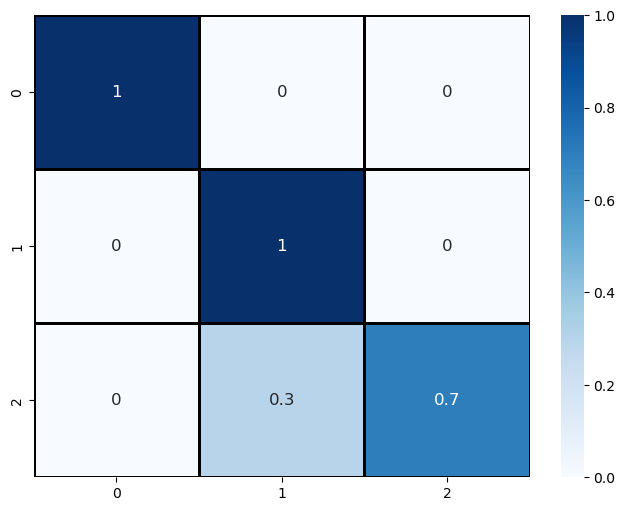

In [53]:
cm = confusion_matrix(y_test, my_model.predict(X_test), normalize='true')
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap='Blues', linecolor='black', linewidths=2, annot_kws={'size': 12})
plt.show()

In [54]:
report = classification_report(y_test, my_model.predict(X_test), output_dict=True)
pd.DataFrame(report).T

,precision,recall,f1-score,support
0,1.000000,1.0,1.000000,10.0
1,0.769231,1.0,0.869565,10.0
2,1.000000,0.7,0.823529,10.0
accuracy,0.900000,0.9,0.900000,0.9
macro avg,0.923077,0.9,0.897698,30.0
weighted avg,0.923077,0.9,0.897698,30.0


In [55]:
df['Model Prediction'] = my_model.predict(X)
df.sample(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,Model Prediction
38,4.4,3.0,1.3,0.2,0,0
54,6.5,2.8,4.6,1.5,1,1
62,6.0,2.2,4.0,1.0,1,1
97,6.2,2.9,4.3,1.3,1,1
32,5.2,4.1,1.5,0.1,0,0
139,6.9,3.1,5.4,2.1,2,2
8,4.4,2.9,1.4,0.2,0,0
49,5.0,3.3,1.4,0.2,0,0
72,6.3,2.5,4.9,1.5,1,1
57,4.9,2.4,3.3,1.0,1,1
